<a href="https://colab.research.google.com/github/NMelbard/PBL1/blob/main/PBL_1_amoxicillin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [10]:
#constants

gamma1 = 0.1 #rate constant for gut to blood absorption
w1 = 0.1 #amount expelled as waste from gut
w2 = 0.1 #amount expelled as waste renally
d = 0.5 #decay rate constant of the antibotic.
gamma2 = 0.1 #rate constant for blood to lung absorption

In [20]:
import math
def A_input(t):
  if math.floor(t) % 8 == 0: #every 8 hours the patient takes the medication.
    return 500
  else:
    return 0

def f(t, y, c):
  """
  c = [gamma1, w1, w2, d, gamma2]
  """
  a_gut, a_blood, a_lung = y

  dagdt = A_input(t) - c[0]*a_gut - c[1]*a_gut #gut
  dabdt = c[0]*a_gut - c[2]*a_blood - c[3]*a_blood - c[4]*a_blood #blood
  daldt = c[4]*a_blood - c[3]*a_lung #lung

  return [dagdt, dabdt, daldt]

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  4.805e-02 ...  4.795e+01  4.800e+01]
        y: [[ 0.000e+00  2.391e+01 ...  1.436e+02  1.428e+02]
            [ 0.000e+00  5.689e-02 ...  2.816e+01  2.790e+01]
            [ 0.000e+00  9.092e-05 ...  7.770e+00  7.719e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 662
     njev: 0
      nlu: 0


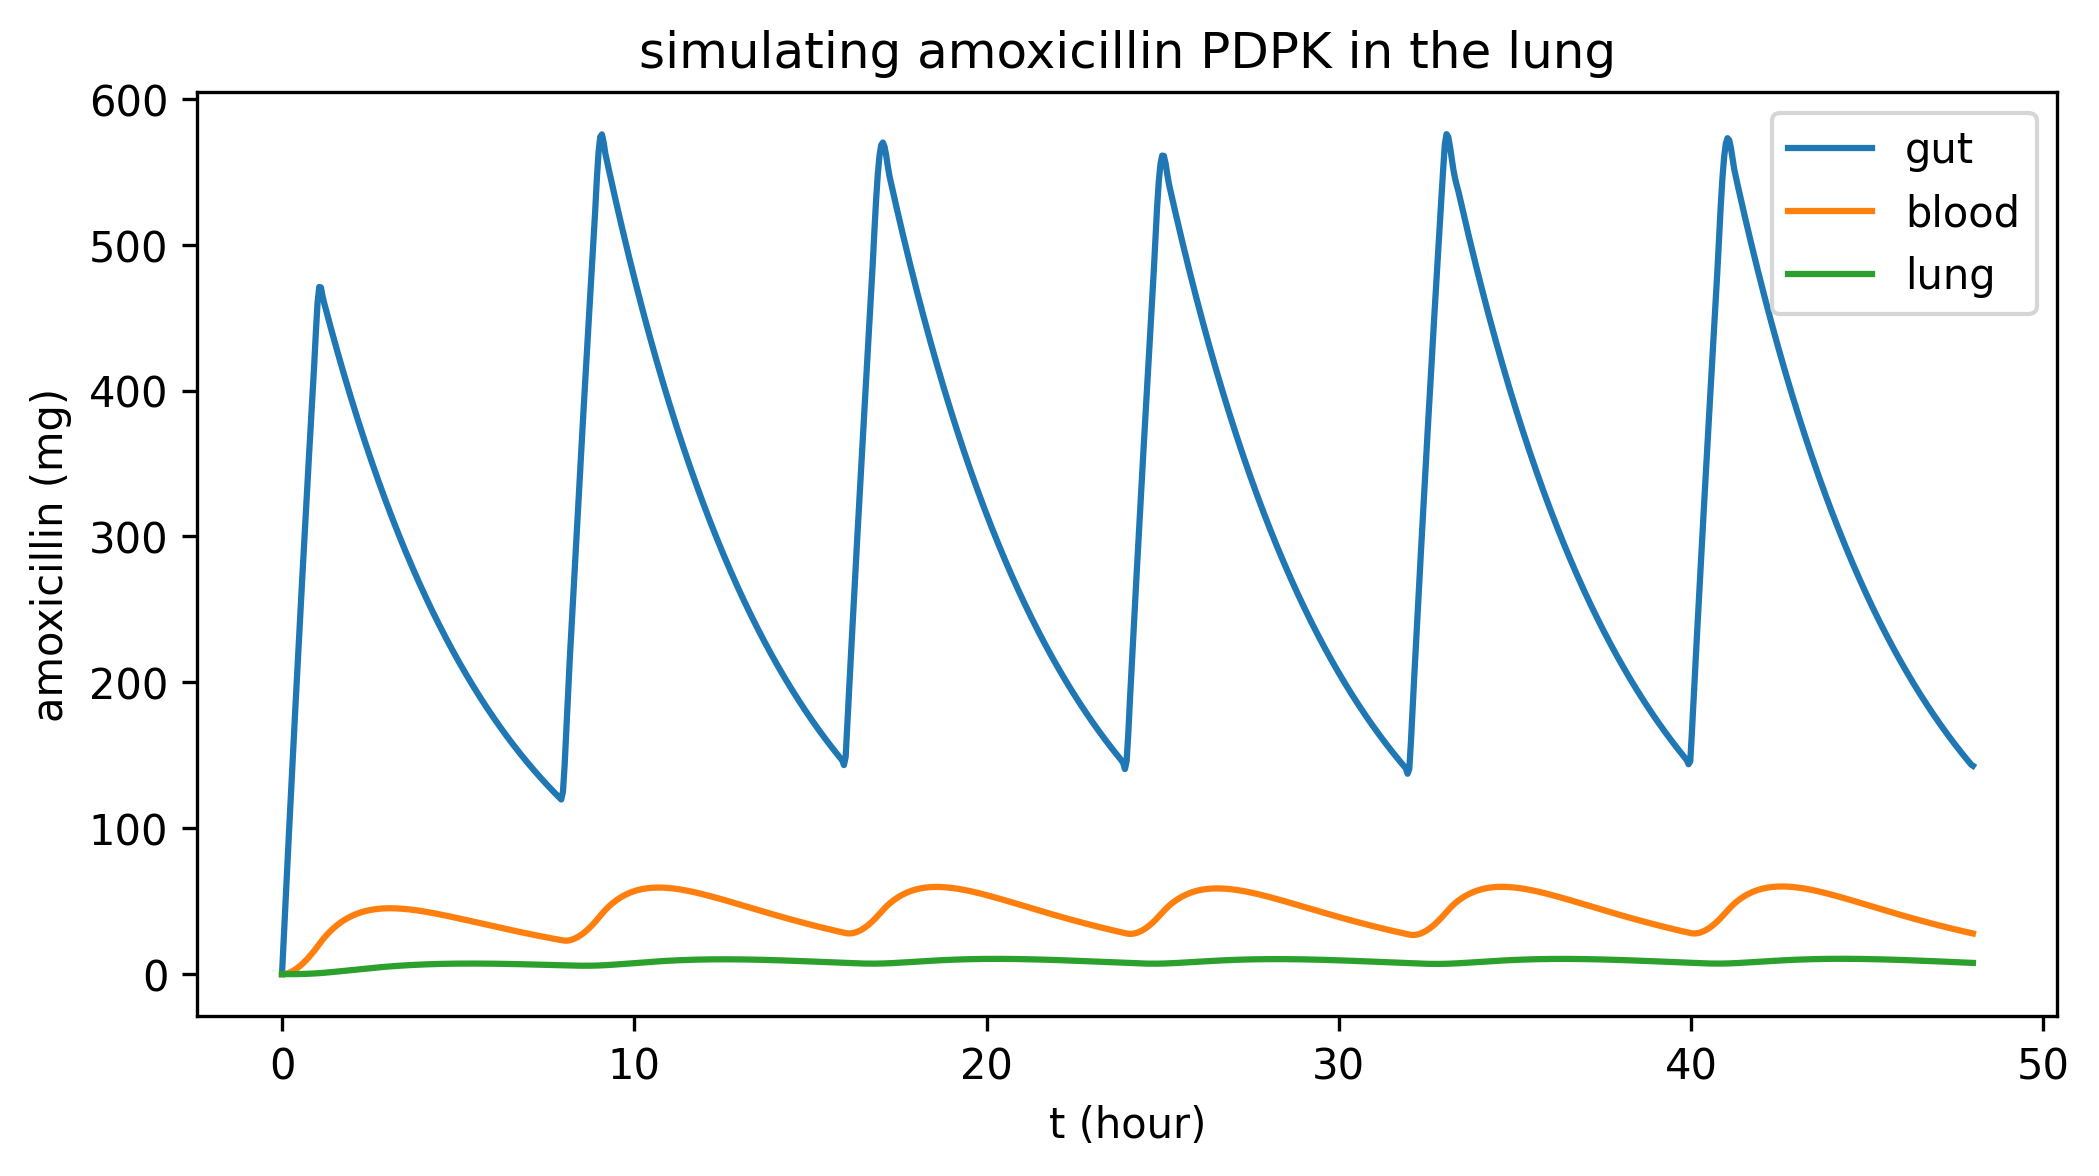

In [23]:
c = [gamma1, w1, w2, d, gamma2]
yinit = [0, 0, 0]

tspan = np.linspace(0, 48, 1000)

sol = solve_ivp(lambda t, y: f(t,y,c), [tspan[0], tspan[-1]], yinit, t_eval=tspan)
print(sol)

plt.figure(figsize=(8,4),dpi=300)
plt.plot(sol.t, sol.y[0], label='gut')
plt.plot(sol.t, sol.y[1], label='blood')
plt.plot(sol.t, sol.y[2], label='lung')
plt.xlabel('t (hour)')
plt.ylabel('amoxicillin (mg)')
plt.legend()
plt.title('simulating amoxicillin PDPK')
plt.show()

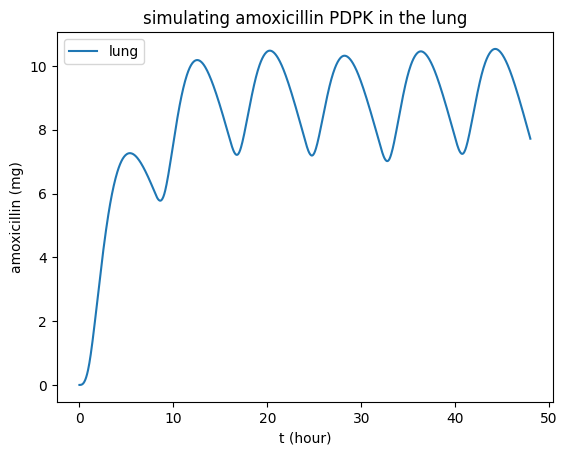

In [24]:
plt.plot(sol.t, sol.y[2], label='lung')
plt.xlabel('t (hour)')
plt.ylabel('amoxicillin (mg)')
plt.legend()
plt.title('simulating amoxicillin PDPK in the lung')
plt.show()